# QPD VNA Simulator

End-to-end demo of `qpd.simulator`: generate a realistic I/Q timeseries of a QPD transmon coupled to a notch-type readout resonator (Probst et al., RSI 86, 024706 (2015), Eq. 1), with quasiparticle tunneling modeled as two independent Poisson processes (Γ_even→odd, Γ_odd→even).

Composable n_g(t) model: a slow sawtooth drift (cf. Fig. 7 top of arXiv:2405.17192) plus discrete charge-jump events.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qpd import (
    QPD,
    VNASimulator,
    ResonatorConfig,
    WhiteGaussianNoise,
    SawtoothNg,
    ChargeJumpEvents,
    ConstantNg,
    QuasiparticleBurstModel,
)

plt.style.use(QPD._style_path)

## 1. Build the QPD device

Pick E_J, E_C in the QPD regime (E_J/E_C ≈ 12 here) and set the transmon–resonator coupling g.

In [2]:
qpd = QPD(e_j_hz=8.335e9, e_c_hz=0.695e9)
qpd.coupling_g_hz = 150e6
print(f'E_J/E_C = {qpd.e_j_hz / qpd.e_c_hz:.2f}')
print(f'g       = {qpd.coupling_g_hz / 1e6:.1f} MHz')

E_J/E_C = 11.99
g       = 150.0 MHz


## 2. Resonator + measurement environment

`ResonatorConfig` carries the resonator parameters (`f_r`, `q_i`, `q_c_abs`, impedance `phi`) and the VNA environment `a, alpha, tau` (which put the output in raw **electronic coordinates**).

Numbers from a recent `resonator_tools` notch fit of a real device:
```
fr = 6489353036.703264 Hz    # measured (DRESSED) line
Qi = 39669.674 ; Qc = 81560.897 ; Ql = 26688.765
kappa = fr/Qc = 79.6 kHz (= kappa_c) ;  total kappa = fr/Ql = 243 kHz
```

The measured `fr` is the **dressed** resonance (qubit pull included). The cQED model uses a *bare* cavity and adds the dispersive shift \(\chi\), so we back-solve the bare `f_r` (fixed point on \(\chi\)) such that the dressed even-parity line lands exactly at the measured `fr`. The readout **LO** `F_DRIVE` is then **independent** of the resonator frequency and is parked **1 kHz above the dressed line** (see §4).

In [3]:
FR, QI, QC, QL = 6489353036.703264, 39669.674, 81560.897, 26688.765
KAPPA, KAPPA_C = FR / QL, FR / QC          # total / coupling-port rates [Hz]

# Measured FR is the DRESSED line; back out the bare cavity so the qubit pull
# places the dressed (even, n_g=0) line at FR (fixed point on chi).
F_BARE = FR
for _ in range(6):
    _, _chi = qpd.compute_dispersive_matrix(0.0, qpd.coupling_g_hz, F_BARE,
                                            num_levels=2, parity='even')
    F_BARE = FR - _chi[0] + 15e6

resonator = ResonatorConfig(f_r=F_BARE, q_i=QI, q_c_abs=QC,
                            phi=0.03, a=0.5, alpha=0.4, tau=50e-9)
F_DRIVE = FR + 1e3                          # readout LO: 1 kHz above the dressed line

print(f'bare cavity  = {F_BARE/1e9:.6f} GHz')
print(f'dressed line = {FR/1e9:.6f} GHz (measured)  ->  readout LO = dressed + 1 kHz')
print(f'f_drive - bare f_r = {(F_DRIVE-F_BARE)/1e6:+.2f} MHz  (LO independent of resonator)')
print(f'Q_l = {resonator.q_l():.0f} (fit {QL:.0f}); '
      f'kappa_total = {KAPPA/1e3:.1f} kHz, kappa_c = {KAPPA_C/1e3:.1f} kHz')

bare cavity  = 6.476410 GHz
dressed line = 6.489353 GHz (measured)  ->  readout LO = dressed + 1 kHz
f_drive - bare f_r = +12.94 MHz  (LO independent of resonator)
Q_l = 26693 (fit 26689); kappa_total = 243.1 kHz, kappa_c = 79.6 kHz


## 3. Offset-charge model

Components compose via `+`. Here: a slow sawtooth ramping at 0.05 /s between ±0.5, plus three discrete charge-jump events.

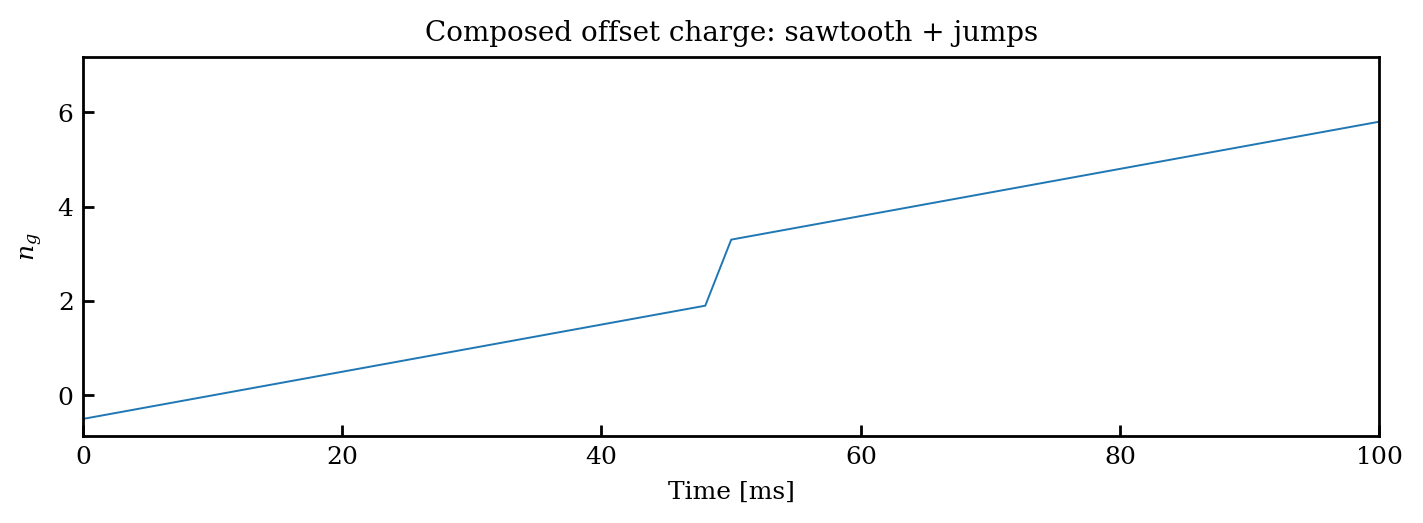

In [4]:
n_g_model = SawtoothNg(
    n_g_min=-0.5, n_g_max=5, slope=50,
) + ChargeJumpEvents(
    times=np.array([0.05, 1.2, 3.5, 7.8]),
    deltas=np.array([+1.3, +0.3, -0.2, +0.4]),
)

# Preview n_g(t)
t_preview = np.linspace(0, 10, 5000)
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.plot(t_preview*1000, n_g_model.evaluate(t_preview), lw=0.7)
ax.set_xlabel('Time [ms]')
ax.set_ylabel(r'$n_g$')
ax.set_title('Composed offset charge: sawtooth + jumps')
plt.xlim(0, 100)
plt.show()

## 4. Run the simulation

Two Poisson rates set the background parity-flip dynamics; their ratio sets the steady-state populations. The readout **LO `f_drive = F_DRIVE` is parked 1 kHz above the dressed resonator line**, independent of the resonator frequency — the simulator now supports any LO \(\neq f_r\) (the dispersive \(\chi\) is computed at the resonator `f_r`, not at the LO).

On top of this background telegraph we superimpose **quasiparticle bursts** from energy-deposition events (`QuasiparticleBurstModel`). Each burst injects a cluster of QP tunneling events (each event = one parity flip) whose times relative to the burst onset follow an **exponentially modified Gaussian (EMG)** profile — `Normal(μ, σ) + Exponential(τ)` — with **τ = 3.7 ms, μ = 1.2 ms, σ = 0.4 ms**. The per-burst count is Poisson (mean ≈ 10) and recorded as ground **truth** (`result.bursts`): onset time, event span, and the true number of tunneling events. Onsets are placed inside the first 100 ms so they land in the §5 zoom.

In [5]:
gamma_e_to_o = 400.0
gamma_o_to_e = 500.0
p_odd_expected = gamma_e_to_o / (gamma_e_to_o + gamma_o_to_e)

# Quasiparticle bursts from energy deposition: EMG tunneling-time profile.
qp_bursts = QuasiparticleBurstModel(
    times=np.array([0.020, 0.055, 0.085]),   # burst onsets [s], within the 100 ms zoom
    tau=3.7e-3, mu=1.2e-3, sigma=0.4e-3,     # EMG params [s]
    expected_n_qp=10.0,                       # Poisson mean tunnels per burst
)

sim = VNASimulator(
    qpd=qpd,
    resonator=resonator,
    f_drive=F_DRIVE,            # readout LO, 1 kHz off the dressed line (!= resonator f_r)
    sample_rate=1e5,
    gamma_even_to_odd=gamma_e_to_o,
    gamma_odd_to_even=gamma_o_to_e,
    noise=WhiteGaussianNoise(sigma=2e-4),
    offset_charge=n_g_model,
    quasiparticle_bursts=qp_bursts,
)

result = sim.simulate(duration=10.0, seed=0)

frac_odd = float(np.mean(result.parity == 1))
print(f'readout LO   = f_r(bare) {(F_DRIVE-F_BARE)/1e6:+.2f} MHz = dressed line + 1 kHz')
print(f'Empirical P(odd) = {frac_odd:.4f}')
print(f'Predicted P(odd) = {p_odd_expected:.4f}')
print(f'Samples          = {result.t.size:,}')
print('\nQuasiparticle burst truth:')
for bt in result.bursts:
    print(f'  burst @ {bt.t_arrival*1e3:6.1f} ms : {bt.n_qp:3d} QP tunnels, '
          f'span {bt.t_start*1e3:.1f}–{bt.t_end*1e3:.1f} ms')

readout LO   = f_r(bare) +12.94 MHz = dressed line + 1 kHz
Empirical P(odd) = 0.4487
Predicted P(odd) = 0.4444
Samples          = 1,000,000

Quasiparticle burst truth:
  burst @   20.0 ms :  11 QP tunnels, span 20.8–33.0 ms
  burst @   55.0 ms :  11 QP tunnels, span 56.6–66.7 ms
  burst @   85.0 ms :   5 QP tunnels, span 86.1–89.7 ms


## 5. Inspect I(t), Q(t)

Zoom into the first 100 ms so individual parity flips are visible. **Top panel:** measured I/Q (baselined voltage). **Bottom panel:** the underlying parity (telegraph) signal *truth* — the even/odd state that drives the dispersive shift. Shaded bands (`axvspan`, on both panels) mark the time span of each quasiparticle burst; the text annotation gives the **true** number of QP tunneling events in that burst (simulation ground truth from `result.bursts`). Inside the burst windows the telegraph switches rapidly — a visible excess of parity flips on top of the background telegraph.

/var/folders/b4/tkxxqysd1pd6vc7155459qcm0000gn/T/ipykernel_2534/1928022876.py:48: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


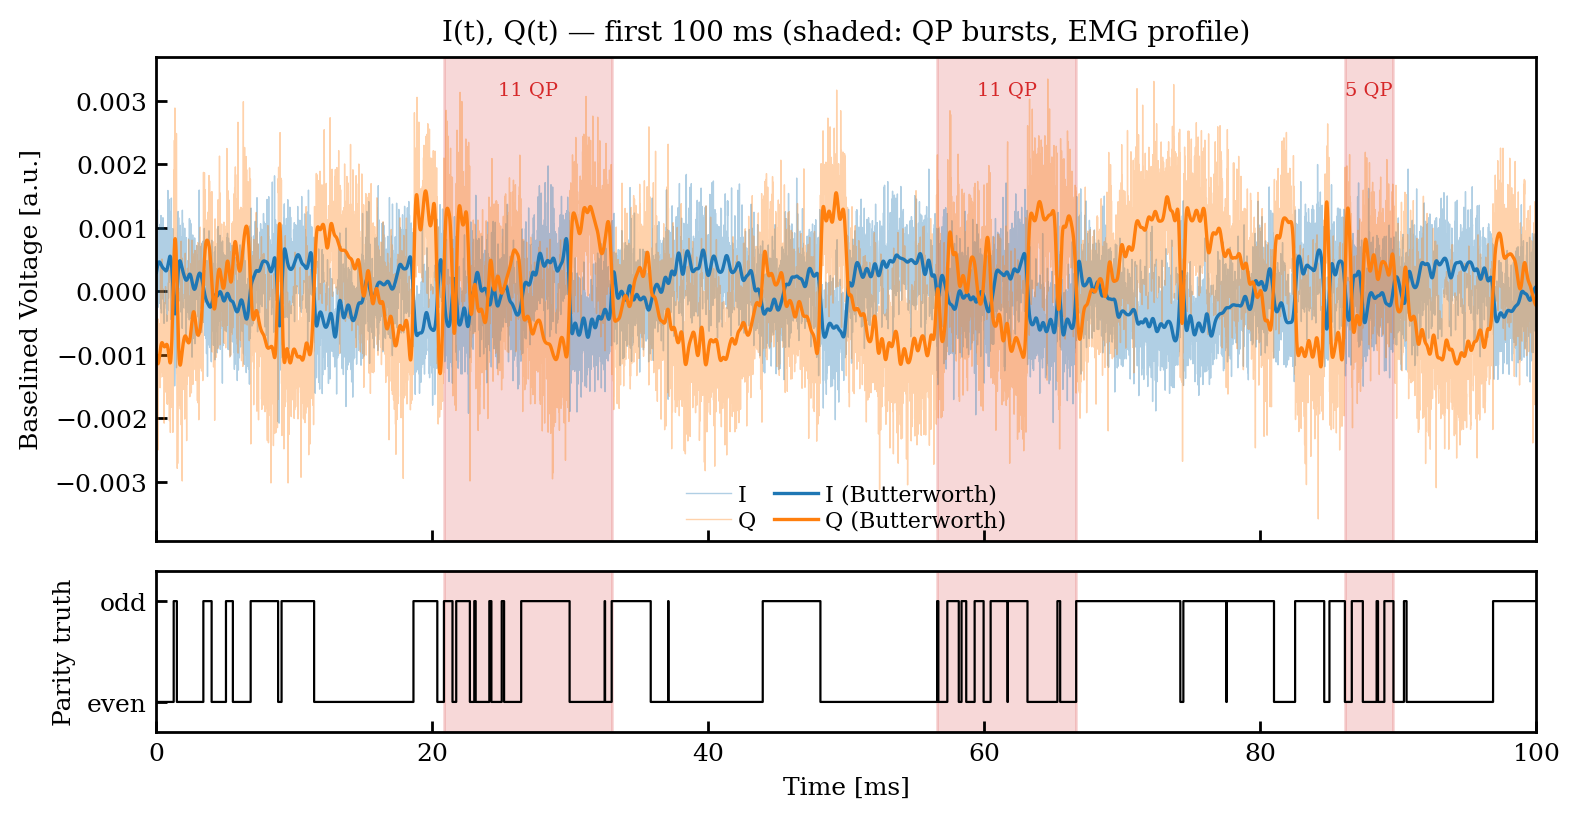

In [6]:
from scipy.signal import butter, filtfilt

zoom = result.t < 0.1
t_ms = result.t[zoom] * 1e3
i_norm = result.i[zoom] / np.mean(result.i[zoom]) - 1
q_norm = result.q[zoom] / np.mean(result.q[zoom]) - 1
parity_zoom = result.parity[zoom]

dt = float(np.mean(np.diff(result.t)))
fs_hz = 1.0 / dt
cutoff_hz = 2_000.0
b, a = butter(N=4, Wn=cutoff_hz, btype='low', fs=fs_hz)
i_filt = filtfilt(b, a, i_norm)
q_filt = filtfilt(b, a, q_norm)

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(8, 4.2), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1]})

# --- Top panel: measured I(t), Q(t) ---
ax.plot(t_ms, i_norm, label='I ', lw=0.5, alpha=0.35)
ax.plot(t_ms, q_norm, label='Q', lw=0.5, alpha=0.35)
ax.plot(t_ms, i_filt, label='I (Butterworth)', lw=1.2, color="tab:blue")
ax.plot(t_ms, q_filt, label='Q (Butterworth)', lw=1.2, color="tab:orange")
ax.set_ylabel('Baselined Voltage [a.u.]')
ax.set_title('I(t), Q(t) — first 100 ms (shaded: QP bursts, EMG profile)')
ax.legend(ncol=2)

# --- Bottom panel: parity (telegraph) signal truth ---
ax2.step(t_ms, parity_zoom, where='post', lw=0.8, color='k')
ax2.set_ylim(-0.3, 1.3)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['even', 'odd'])
ax2.set_xlabel('Time [ms]')
ax2.set_ylabel('Parity truth')

# Overlay quasiparticle-burst truth on BOTH panels: shade each burst's time span,
# annotate the true number of QP tunneling events (top panel).
y_top = ax.get_ylim()[1]
for bt in result.bursts:
    if bt.n_qp == 0:
        continue
    ax.axvspan(bt.t_start * 1e3, bt.t_end * 1e3, color="C3", alpha=0.18, zorder=0)
    ax2.axvspan(bt.t_start * 1e3, bt.t_end * 1e3, color="C3", alpha=0.18, zorder=0)
    ax.text((bt.t_start + bt.t_end) / 2 * 1e3, y_top * 0.9,
            f'{bt.n_qp} QP', ha="center", va="top", fontsize=7, color="C3")

ax.set_xlim(0, 100)
fig.tight_layout()
plt.show()

## 6. n_g(t) trajectory used by the simulator

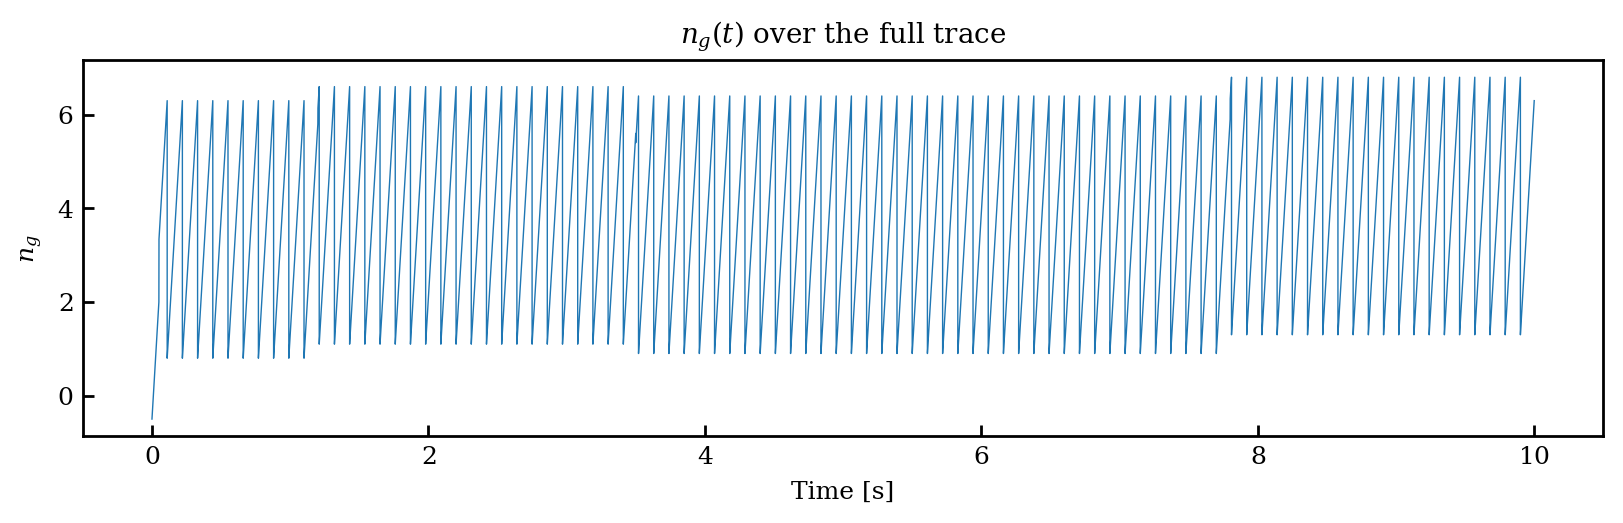

In [7]:
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(result.t, result.n_g, lw=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$n_g$')
ax.set_title(r'$n_g(t)$ over the full trace')
plt.show()